## UPI Transactions & Digital Payments Fraud Detection Using Ensemble Learning

Author: Mayur Pawar
Goal
Predict whether a UPI/digital payment transaction is fraudulent or legitimate using ensemble machine-learning algorithms and analyze customer transaction behavior.

### 1. Problem Statement
Digital payment platforms process a large number of UPI transactions every day. Fraudulent transactions can result in financial losses for customers, banks, and payment providers.
The objective of this project is to develop a machine-learning system that predicts whether a transaction is Fraudulent (1) or Legitimate (0) based on transaction characteristics and customer behavior.
This is framed as a binary classification problem.

### 2. Business Use Case
Accurate fraud detection can help digital payment companies:
- Detect suspicious transactions before completing payment.
- Reduce financial losses.
- Identify unusual customer behavior.
- Improve transaction security.
- Reduce false fraud alerts.
- Prioritize high-risk transactions for manual investigation.
- Understand customer transaction patterns.

## 3. Dataset

Size:20,000+ transaction records
Target variable
Fraud
0 → Legitimate
1 → Fraudulent


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load Dataset

In [3]:
df = pd.read_excel("UPI_Digital_Payment_Fraud_Dataset_20000.xlsx")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (20000, 17)


,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Merchant_Category,Payment_Method,Device_Type,Location,Customer_Age,Account_Age_Days,Previous_Transactions,Avg_Transaction_Amount,Transactions_Last_24h,Failed_Transactions,New_Device,International_IP,Fraud
0,TXN000001,CUST00861,289.39,P2P,Entertainment,QR,iOS,Hyderabad,45.0,1994,1,1223.00,9,2.0,0,0,0
1,TXN000002,CUST03773,6118.52,Recharge,Retail,UPI ID,Android,Kolkata,37.0,1727,54,1653.91,18,0.0,0,0,1
2,TXN000003,CUST03093,5652.94,P2P,Retail,UPI,Android,Delhi,46.0,1422,187,1469.32,10,3.0,0,0,0
3,TXN000004,CUST00467,878.10,P2M,Utilities,QR,Android,Ahmedabad,43.0,879,261,210.66,6,3.0,0,0,0
4,TXN000005,CUST04427,6536.77,Online Shopping,Travel,QR,Android,Kolkata,34.0,1097,197,727.92,11,2.0,0,0,0


## 3. Basic Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Transaction_ID          20000 non-null  object 
 1   Customer_ID             20000 non-null  object 
 2   Transaction_Amount      19840 non-null  float64
 3   Transaction_Type        20000 non-null  object 
 4   Merchant_Category       19801 non-null  object 
 5   Payment_Method          19840 non-null  object 
 6   Device_Type             19879 non-null  object 
 7   Location                19839 non-null  object 
 8   Customer_Age            19880 non-null  float64
 9   Account_Age_Days        20000 non-null  int64  
 10  Previous_Transactions   20000 non-null  int64  
 11  Avg_Transaction_Amount  19802 non-null  float64
 12  Transactions_Last_24h   20000 non-null  int64  
 13  Failed_Transactions     19840 non-null  float64
 14  New_Device              20000 non-null

In [6]:
df.describe()

,Transaction_Amount,Customer_Age,Account_Age_Days,Previous_Transactions,Avg_Transaction_Amount,Transactions_Last_24h,Failed_Transactions,New_Device,International_IP,Fraud
count,19840.000000,19880.000000,20000.000000,20000.000000,19802.000000,20000.000000,19840.000000,20000.000000,20000.000000,20000.000000
mean,1804.792095,40.967203,1272.342150,247.365600,858.051045,11.976400,3.522026,0.149600,0.050850,0.312600
std,2354.949503,13.528169,710.503816,143.277737,697.595039,7.210357,2.304839,0.356688,0.219697,0.463564
min,25.000000,18.000000,30.000000,0.000000,47.880000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,559.115000,29.000000,656.000000,124.000000,417.787500,6.000000,1.000000,0.000000,0.000000,0.000000
50%,1093.410000,41.000000,1274.000000,246.000000,670.695000,12.000000,4.000000,0.000000,0.000000,0.000000
75%,2151.637500,53.000000,1891.000000,370.000000,1069.652500,18.000000,6.000000,0.000000,0.000000,1.000000
max,56302.990000,64.000000,2499.000000,499.000000,11550.650000,24.000000,7.000000,1.000000,1.000000,1.000000


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Transaction_ID              0
Customer_ID                 0
Transaction_Amount        160
Transaction_Type            0
Merchant_Category         199
Payment_Method            160
Device_Type               121
Location                  161
Customer_Age              120
Account_Age_Days            0
Previous_Transactions       0
Avg_Transaction_Amount    198
Transactions_Last_24h       0
Failed_Transactions       160
New_Device                  0
International_IP            0
Fraud                       0
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 100


## 4. Fraud Distribution

Fraud
0    13748
1     6252
Name: count, dtype: int64


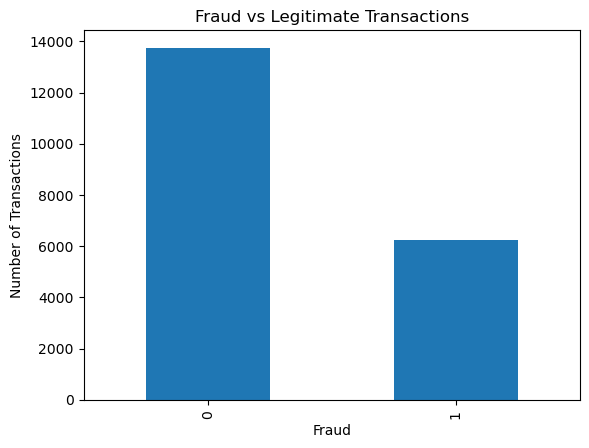

In [10]:
print(df["Fraud"].value_counts())

df["Fraud"].value_counts().plot(
    kind="bar",
    title="Fraud vs Legitimate Transactions"
)

plt.xlabel("Fraud")
plt.ylabel("Number of Transactions")
plt.show()

## 5. Remove Duplicate Records

In [11]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (19900, 17)


## 6. Feature Engineering

In [12]:
df["Amount_Ratio"] = (
    df["Transaction_Amount"] /
    df["Avg_Transaction_Amount"].replace(0, np.nan)
)

df["Failed_Transaction_Rate"] = (
    df["Failed_Transactions"] /
    (df["Transactions_Last_24h"] + 1)
)

df["High_Amount"] = (
    df["Transaction_Amount"] > 50000
).astype(int)

df["High_Frequency"] = (
    df["Transactions_Last_24h"] > 10
).astype(int)

## 7. Define X and y

In [13]:
X = df.drop(
    ["Fraud", "Transaction_ID", "Customer_ID"],
    axis=1
)

y = df["Fraud"]

## 8. Identify Numerical and Categorical Features

In [14]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['Transaction_Amount', 'Customer_Age', 'Account_Age_Days', 'Previous_Transactions', 'Avg_Transaction_Amount', 'Transactions_Last_24h', 'Failed_Transactions', 'New_Device', 'International_IP', 'Amount_Ratio', 'Failed_Transaction_Rate', 'High_Amount', 'High_Frequency']

Categorical Features:
['Transaction_Type', 'Merchant_Category', 'Payment_Method', 'Device_Type', 'Location']


## 9. Preprocessing Pipeline

In [15]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

## 10. Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (15920, 18)
Testing Data: (3980, 18)


## 11. Ensemble Models
### Random Forest

In [18]:
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

### Extra Trees

In [19]:
et = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

### Gradient Boosting

In [20]:
gb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=3,
        random_state=42
    ))
])

## AdaBoost

In [22]:
ab = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostClassifier(
        n_estimators=150,
        learning_rate=0.08,
        random_state=42
    ))
])

## 12. Train All Ensemble Models

In [24]:
models = {
    "Random Forest": rf,
    "Extra Trees": et,
    "Gradient Boosting": gb,
    "AdaBoost": ab
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.719347,0.596677,0.317269,0.414263,0.735060
0,Random Forest,0.714070,0.590219,0.281124,0.380849,0.729706
1,Extra Trees,0.709799,0.572581,0.285141,0.380697,0.718703
3,AdaBoost,0.721106,0.631579,0.260241,0.368601,0.738443


## 13. Model Comparison

In [25]:
results_df = results_df.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

print(results_df)

               Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Gradient Boosting  0.719347   0.596677  0.317269  0.414263  0.735060
1      Random Forest  0.714070   0.590219  0.281124  0.380849  0.729706
2        Extra Trees  0.709799   0.572581  0.285141  0.380697  0.718703
3           AdaBoost  0.721106   0.631579  0.260241  0.368601  0.738443


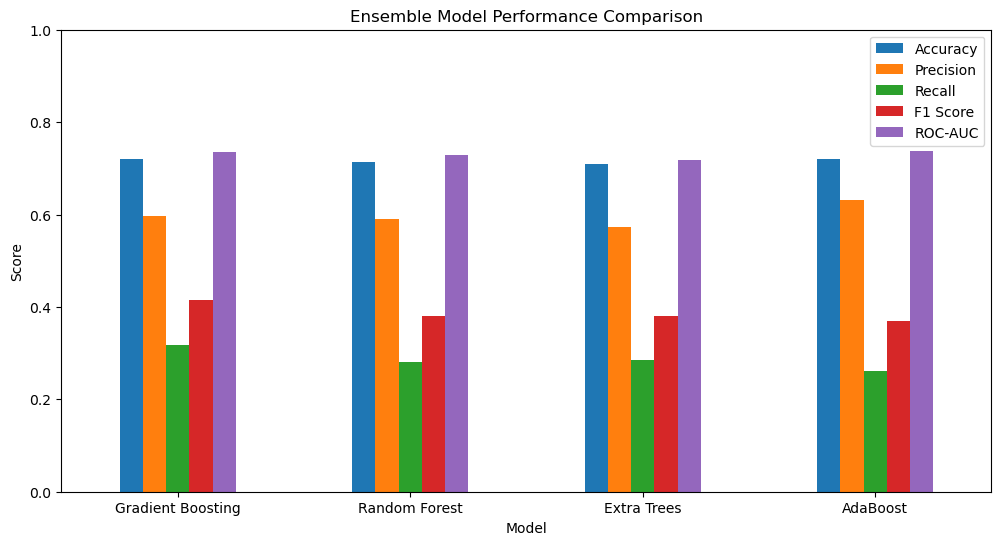

In [26]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Ensemble Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## 14. Select Best Ensemble Model

In [27]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Ensemble Model:", best_model_name)
best_model = models[best_model_name]

Best Ensemble Model: Gradient Boosting


## 15. Classification Report

In [28]:
y_pred = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"]
    )
)

              precision    recall  f1-score   support

  Legitimate       0.74      0.90      0.82      2735
       Fraud       0.60      0.32      0.41      1245

    accuracy                           0.72      3980
   macro avg       0.67      0.61      0.61      3980
weighted avg       0.70      0.72      0.69      3980



## 16. Confusion Matrix

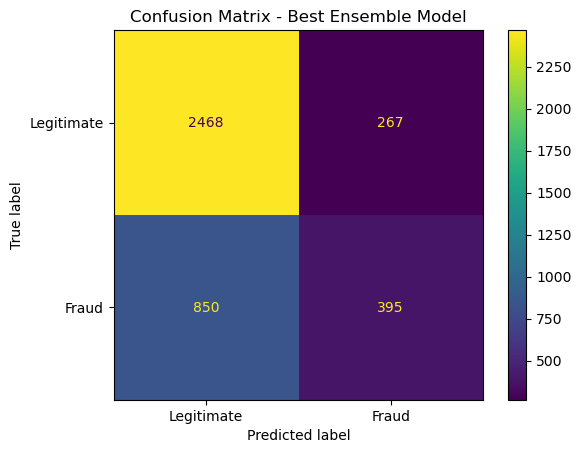

In [29]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Confusion Matrix - Best Ensemble Model")
plt.show()

## 17. ROC Curve

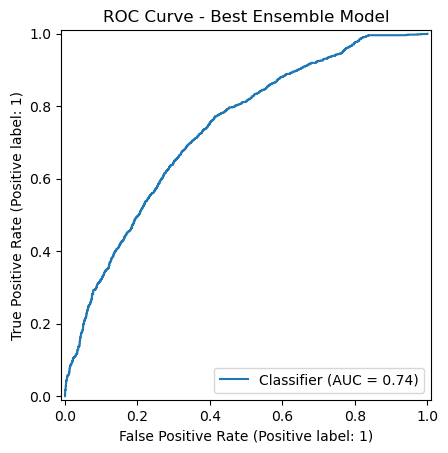

In [30]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    best_model.predict_proba(X_test)[:, 1]
)

plt.title("ROC Curve - Best Ensemble Model")
plt.show()

## 18. Final Prediction

In [31]:
new_transaction = pd.DataFrame({
    "Transaction_Amount": [75000],
    "Transaction_Type": ["P2P"],
    "Merchant_Category": ["E-Commerce"],
    "Payment_Method": ["UPI"],
    "Device_Type": ["Android"],
    "Location": ["Pune"],
    "Customer_Age": [25],
    "Account_Age_Days": [45],
    "Previous_Transactions": [20],
    "Avg_Transaction_Amount": [1500],
    "Transactions_Last_24h": [15],
    "Failed_Transactions": [4],
    "New_Device": [1],
    "International_IP": [1],
    "Amount_Ratio": [50],
    "Failed_Transaction_Rate": [0.25],
    "High_Amount": [1],
    "High_Frequency": [1]
})

prediction = best_model.predict(new_transaction)[0]
probability = best_model.predict_proba(new_transaction)[0][1]

print("Fraud Probability:", round(probability * 100, 2), "%")

if prediction == 1:
    print("Prediction: FRAUDULENT TRANSACTION")
else:
    print("Prediction: LEGITIMATE TRANSACTION")

Fraud Probability: 79.78 %
Prediction: FRAUDULENT TRANSACTION


## 19. Save Best Model

In [32]:
import joblib

joblib.dump(
    best_model,
    "UPI_Fraud_Ensemble_Model.pkl"
)

print("Best ensemble model saved successfully.")

Best ensemble model saved successfully.
